# Anchor/ELI5
## Przegląd narzędzia

## Cel zajęć

Po zajęciach student:

* rozumie ideę **Anchor explanations**
* zna podstawy biblioteki **ELI5**
* potrafi porównać je z LIME i SHAP
* wie, kiedy ich używać

## 1. Dlaczego jeszcze inne metody?

Mamy już:

* LIME → lokalne, ale losowe
* SHAP → stabilne, ale czasem trudne

Pytanie:

> „Czy da się mieć wyjaśnienie, które jest proste jak reguła?”

Potrzeba stosowania różnych metod wyjaśniania modeli wynika z faktu, że nie istnieje jedno uniwersalne podejście, które byłoby jednocześnie w pełni wierne modelowi, stabilne, łatwe do zrozumienia i odpowiednie dla każdego typu problemu oraz odbiorcy. Metody takie jak LIME, SHAP czy PDP odpowiadają na różne pytania (lokalne vs globalne, przybliżenie vs dekompozycja, średni wpływ vs indywidualne decyzje) i mają swoje ograniczenia, np. losowość (LIME), złożoność obliczeniową (SHAP) czy uśrednianie efektów (PDP). W praktyce potrzebujemy więc różnych narzędzi, które pozwalają spojrzeć na model z wielu perspektyw – jedne lepiej nadają się do analizy technicznej, inne do komunikacji z użytkownikiem czy ekspertem domenowym. Dodatkowo różne formy wyjaśnień (liczbowe, wizualne, regułowe) odpowiadają różnym potrzebom poznawczym ludzi, dlatego stosowanie wielu metod zwiększa zarówno wiarygodność interpretacji, jak i jej użyteczność w rzeczywistych zastosowaniach.

## 2. Anchor – idea

Anchor to metoda wyjaśniania lokalnych predykcji modeli uczenia maszynowego, która przedstawia decyzję modelu w postaci prostych, zrozumiałych reguł typu „jeśli–to”, nazywanych kotwicami (ang. anchors). Ideą tej metody jest znalezienie minimalnego zestawu warunków na wartościach cech, które są wystarczające, aby model z dużym prawdopodobieństwem (wysoką precyzją) podjął tę samą decyzję, niezależnie od pozostałych zmiennych. Innymi słowy, anchor określa fragment przestrzeni danych, w którym predykcja modelu jest stabilna i przewidywalna. Metoda działa poprzez generowanie perturbacji danych wokół analizowanej obserwacji i wyszukiwanie takich kombinacji warunków, które „zakotwiczają” decyzję modelu, zapewniając jej niezmienność w tym lokalnym obszarze. Dzięki temu Anchor oferuje bardzo intuicyjne, regułowe wyjaśnienia, które są szczególnie przydatne w komunikacji z użytkownikami nietechnicznymi, choć pozostają lokalne i zależne od przyjętego sposobu próbkowania danych.

> Anchor to zestaw warunków (reguł), które „zakotwiczają” decyzję modelu.

### Intuicja

Zamiast:

> „cecha A daje +0.23”

dostajesz:

> „JEŚLI A > 10 i B < 5 → model prawie zawsze daje tę samą decyzję”

Anchor = warunki, które:

* są **wystarczające** do podjęcia decyzji
* gwarantują wysoką **precyzję (precision)**

## 3. Jak działa Anchor

Anchor działa poprzez znajdowanie minimalnego zestawu warunków na cechach, które wystarczają do „zakotwiczenia” decyzji modelu dla danej obserwacji, czyli zapewniają, że predykcja pozostaje taka sama z wysokim prawdopodobieństwem nawet przy zmianie pozostałych cech. Algorytm rozpoczyna od wybranej próbki, a następnie generuje wiele jej losowych perturbacji (zmodyfikowanych wersji), dla których oblicza predykcje modelu. Kolejno przeszukuje przestrzeń możliwych reguł (np. „cecha A > próg”, „cecha B ≤ próg”), stopniowo budując kombinacje warunków i oceniając ich jakość na podstawie dwóch miar: precyzji (jak często przy spełnieniu reguły model daje tę samą decyzję) oraz pokrycia (jak duży fragment danych spełnia tę regułę). Proces ten często wykorzystuje strategię eksploracji podobną do multi-armed bandit, aby efektywnie znaleźć krótkie i wiarygodne reguły. Wynikiem jest anchor – zbiór warunków, który gwarantuje stabilność predykcji w lokalnym otoczeniu analizowanej obserwacji, co pozwala zrozumieć, kiedy i dlaczego model podejmuje daną decyzję.

### Intuicyjnie

1. wybieramy obserwację
2. generujemy perturbacje (jak w LIME)
3. szukamy zestawu warunków (reguł)
4. sprawdzamy: 
    > Jak często decyzja modelu się nie zmienia

> Anchor mówi: „jeśli te warunki są spełnione, model NA PEWNO podejmie taką decyzję”

## 4. Przykład

```text
IF mean radius > 15 AND mean texture < 20
THEN prediction = malignant (precision = 0.95)
```

### Interpretacja

* reguła lokalna
* działa tylko w pewnym obszarze
* bardzo intuicyjna

## 5. Zalety i ograniczenia Anchor

### Zalety

- bardzo czytelne
- przypomina drzewa decyzyjne
- łatwe do komunikacji

### Ograniczenia

- lokalne
- może być trudne znalezienie krótkiej reguły
- zależne od perturbacji

## 6. Warsztat – Anchor

Biblioteka Alibi to narzędzie do wyjaśniania modeli uczenia maszynowego, które oferuje implementację metody Anchor w postaci klasy `AnchorTabular`, umożliwiającej generowanie lokalnych wyjaśnień w formie reguł typu „jeśli–to” dla danych tabelarycznych. W praktyce użytkownik przekazuje do niej wytrenowany model (najczęściej funkcję predykcyjną, np. `predict`) oraz dane treningowe, na podstawie których Alibi estymuje rozkład cech potrzebny do generowania realistycznych perturbacji. Następnie dla wybranej obserwacji metoda `explain` wyszukuje zestaw warunków (anchor), które zapewniają wysoką stabilność predykcji modelu, zwracając przy tym nie tylko samą regułę, ale również jej jakość w postaci miar takich jak precision (jak często reguła prowadzi do tej samej decyzji) oraz coverage (jak często warunki są spełnione w danych). Dzięki temu Alibi pozwala łatwo zastosować metodę Anchor w praktyce, oferując czytelne, regułowe wyjaśnienia decyzji modelu, które są szczególnie użyteczne w komunikacji z użytkownikami nietechnicznymi, przy zachowaniu kontroli nad ich wiarygodnością.

In [ ]:
%pip install alibi

Przy instalacji mogą pojawić się błędy, zaleca się użycie konkretnych wersji bibliotek (dla python 3.10.11):

Mogą posłużyć do tego komendy:

```bash
python3 -m pip uninstall keras
```

A następnie

```bash
python3 -m pip install --upgrade --no-deps --force-reinstall tensorflow numpy protobuf typing-extensions
```

A czasem (_**w 99% przypadków :)**_) prościej jest to zrobić w środowisku [conda](https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html). Wtedy prawodpodobnie wystarczy jedynie instalacja biblioteki `alibi`, a reszta zależności powinna doinstalować się sama.

Środowisko `Conda` (np. w dystrybucji Anaconda lub Miniconda) to narzędzie do zarządzania pakietami i izolowanymi środowiskami, które pozwala pracować nad modelami AI w sposób powtarzalny, stabilny i wolny od konfliktów zależności. Jego kluczową zaletą jest możliwość tworzenia odrębnych środowisk z konkretnymi wersjami Pythona i bibliotek (np. różne wersje `numpy`, `scikit-learn`, `tensorflow`), co eliminuje typowe problemy typu „działa u mnie, nie działa u Ciebie” oraz błędy binarne wynikające z niezgodności pakietów. Conda rozwiązuje też zależności na poziomie binarnym (C/C++), co jest szczególnie ważne w AI, gdzie wiele bibliotek (np. SHAP, PyTorch) korzysta z rozszerzeń niskopoziomowych. W praktyce workflow wygląda tak: tworzysz środowisko (`conda create -n xai python=3.10`), aktywujesz je (`conda activate xai`), instalujesz pakiety (`conda install numpy pandas scikit-learn` lub `pip install shap eli5 alibi`), a następnie pracujesz w nim w narzędziach takich jak Visual Studio Code czy Jupyter Notebook, wybierając odpowiedni interpreter. Dodatkowo możesz eksportować konfigurację (`conda env export > environment.yml`) i odtwarzać środowisko na innych maszynach (`conda env create -f environment.yml`), co jest kluczowe w projektach badawczych i zespołowych. Dzięki temu Conda nie tylko upraszcza instalację bibliotek, ale przede wszystkim zapewnia kontrolę nad eksperymentami, reprodukowalność wyników i bezpieczeństwo pracy z różnymi stosami technologicznymi.

Tak przygotowane środowisko condy czytane jest jak standardowe środowisko python o konkretnej wersji, zatem VisualStudio Code powinno samo znaleźć i umożliwić korzystanie z tego środowiska chociażby w Jupyterze bez większych problemów.

Pomocne linki:
- [Zarządzanie środowiskami w `conda`](https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html)
- [Konfigurowanie pierwszego środowiska `conda`](https://www.anaconda.com/docs/getting-started/guides/ides/vscode)
- [Konfiguracja środowiska `conda` do VS Code](https://www.anaconda.com/docs/getting-started/guides/ides/vscode)

In [1]:
import warnings
warnings.filterwarnings("ignore")

### Standardowy zestaw importów i operacji przygotowujących model

In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [4]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.956140350877193

### Przykładowe wykorzystanie Anchor 

In [7]:
from alibi.explainers import AnchorTabular

Utworzymy obiekt wyjaśniający metodą Anchor (AnchorTabular), przekazując do niego wytrenowany model oraz nazwy cech, a następnie dopasujemy go do danych treningowych, aby mógł generować realistyczne perturbacje potrzebne do budowy reguł. W kolejnych krokach przejdziemy przez pierwsze obserwacje ze zbioru testowego i dla każdej z nich wygenerujemy lokalne wyjaśnienie w postaci reguły typu „jeśli–to” (anchor), która opisuje warunki wystarczające do podjęcia danej decyzji przez model. Dla każdej reguły wypiszemy jej treść (czyli konkretne warunki na cechach), precyzję (jak często decyzja modelu pozostaje taka sama przy spełnieniu tych warunków) oraz pokrycie (jak duża część danych spełnia tę regułę), a na końcu pokażemy rzeczywistą decyzję modelu dla danej obserwacji, aby móc powiązać wyjaśnienie z konkretną predykcją.


In [ ]:
explainer = AnchorTabular(
    predictor=model.predict,
    feature_names=X_train.columns.tolist()
)

explainer.fit(X_train.values)

i = 0
for i in range(10):
    print(f"=======Instance no. {i}:=======")
    explanation = explainer.explain(X_test.iloc[i].values)

    print("Anchor:", explanation.anchor)
    print("Precision:", explanation.precision)
    print("Coverage:", explanation.coverage)
    print("Decision: ", model.predict(X_test.iloc[i].values.reshape(1, -1))[0])

=======Instance no. 0:=======
Anchor: ['mean concavity > 0.13', 'worst area > 1033.50']
Precision: 0.9944392956441149
Coverage: 0.1766
Decision:  0
=======Instance no. 1:=======
Anchor: ['compactness error <= 0.02', 'worst perimeter <= 83.72']
Precision: 1.0
Coverage: 0.1582
Decision:  1
=======Instance no. 2:=======
Anchor: ['fractal dimension error > 0.00', 'mean concavity > 0.13', 'mean texture > 21.71']
Precision: 1.0
Coverage: 0.1105
Decision:  0
=======Instance no. 3:=======
Anchor: ['radius error > 0.32', 'mean area > 770.05']
Precision: 0.9736486486486486
Coverage: 0.2251
Decision:  0
=======Instance no. 4:=======
Anchor: ['mean smoothness > 0.09', 'worst perimeter > 124.95']
Precision: 0.9878048780487805
Coverage: 0.2373
Decision:  0
=======Instance no. 5:=======
Anchor: ['worst concave points <= 0.16', 'area error <= 17.73']
Precision: 0.9896973599484868
Coverage: 0.2427
Decision:  1
=======Instance no. 6:=======
Anchor: ['worst concave points <= 0.16', 'worst perimeter <= 83

### Wynik

* `anchor` → lista warunków
* `precision` → jak często działa
* `coverage` → dla jakiej części danych

### Dlaczego Anchor daje tylko jedną regułę?

Bo Anchor odpowiada na pytanie:

> Jaki jest NAJPROSTSZY warunek, który wystarczy do decyzji?

### Interpretacja tych wyników

W większości anchorów pojawiają się:

* `worst perimeter`, `worst area`, `mean area`
* `concavity`, `compactness`

Czyli:

> model głównie opiera się na **rozmiarze guza i jego nieregularności**

To jest **bardzo sensowne medycznie**

#### Jak czytać pojedynczy anchor

Weźmy przykład:

```text
=======Instance no. 0:=======
Anchor: ['mean concavity > 0.13', 'worst area > 1033.50']
Precision: 0.9944392956441149
Coverage: 0.1766
Decision:  0
```

Interpretacja:

> Jeśli guz jest nieregularny i duży → model prawie zawsze mówi „złośliwy

* **Precision ~1** → reguła bardzo pewna
* **Coverage ~17,7%** → dotyczy ~17,7% danych

---

Kolejne przypadki dla klasy 0 - złośliwy rak (2, 3, 4, 7, 8, 9)

Wspólne cechy:
- duży rozmiar (area, perimeter)
- nieregularność (concavity, symmetry, texture)
- czasem błędy pomiaru (error)

Interpretacja:
> „duży + nieregularny + złożona struktura → złośliwy”

---

Przykład z drugiej klasy (1 - łagodny)

```text
=======Instance no. 1:=======
Anchor: ['compactness error <= 0.02', 'worst perimeter <= 83.72']
Precision: 1.0
Coverage: 0.1582
Decision:  1
```

Interpretacja:
> Mały i regularny guz → model mówi „łagodny”

---

Kolejne przypadki łagodnego (5, 6)

```text
['worst concave points <= 0.16', 'area error <= 17.73']
['worst concave points <= 0.16', 'worst perimeter <= 83.72']
```

Interpretacja:
> „brak nieregularności + mały rozmiar → łagodny”


#### Kluczowa obserwacja

Anchor pokazuje bardzo wyraźnie, że model wyłapuje głównie zależności:

```text
IF (duży + nieregularny) → złośliwy
IF (mały + regularny) → łagodny
```

---

#### Precision vs Coverage

- Precision (~0.97 – 1.0)

Oznacza:

> „reguły są bardzo pewne, jeśli reguła zachodzi → model prawie nigdy się nie myli”

- Coverage (0.11 – 0.24)

Oznacza, że reguły:
> - nie są globalne
> - obejmują sensowne fragmenty danych

**Przykład:**

```text
Instance 2:
Coverage: 0.1105
```

Bardzo wąska reguła:

> działa świetnie, ale dla małej liczby przypadków (bardziej „precyzyjna diagnoza”)

---

Mamy tutaj klasyczny trade-off:

> im wyższa precision → tym niższe coverage

---

### Co to mówi o modelu?

Model:

* używa sensownych cech
* jest spójny
* nie opiera się na śmieciach

To jest bardzo dobry znak!

---

Można zatem wysnuć wniosek:

> „Model nauczył się bardzo intuicyjnych reguł: duże i nieregularne guzy są złośliwe, a małe i regularne łagodne.”

---

W decyzjach pojawiają się cechy typu:
- error
- fractal dimension error
- compactness error

To oznacza, że model korzysta też z niestabilności pomiarów / wariancji cech.

Można zatem wysnuć wniosek:

> bardziej „chaotyczne” lub zmienne struktury → częściej złośliwy

### Czy te reguły są prawdziwe biologicznie, czy tylko dla tego modelu?

W tym przypadku- **i jedno i drugie**:

* częściowo prawdziwe
* częściowo dopasowane do danych

---

### Finalna konkluzja o metodzie

> Anchor pokazuje nie „dlaczego model tak myśli”, tylko „kiedy model NA PEWNO tak myśli”.


## 7. ELI5 – idea

`ELI5` (Explain Like I’m 5) to podejście oraz biblioteka w Pythonie służąca do wyjaśniania działania modeli uczenia maszynowego w możliwie prosty i zrozumiały sposób, poprzez prezentowanie wpływu poszczególnych cech na predykcję w formie intuicyjnych zestawień (np. list wag, kolorowych tabel czy rankingów cech). Ideą ELI5 nie jest jedna konkretna metoda wyjaśniania, lecz dostarczenie zestawu narzędzi, które upraszczają interpretację różnych modeli (szczególnie tych ze scikit-learn), pokazując, które cechy zwiększają lub zmniejszają wynik modelu oraz z jaką siłą. W przypadku pojedynczej obserwacji ELI5 prezentuje wkład cech podobnie do modeli liniowych (nawet dla bardziej złożonych modeli, korzystając np. z permutation importance), co pozwala użytkownikowi szybko zrozumieć, „co wpłynęło na decyzję modelu” bez konieczności zagłębiania się w szczegóły matematyczne. Dzięki temu ELI5 jest szczególnie przydatne do szybkiej diagnostyki modeli i komunikacji wyników w przystępnej formie.


### Co potrafi?

* pokazuje wagi modeli liniowych
* wyjaśnia predykcje
* wspiera drzewa i modele sklearn

## 8. Warsztat – ELI5

In [ ]:
!pip install eli5

### Feature importance

In [8]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(model, random_state=42)
perm.fit(X_test, y_test)

eli5.show_weights(perm, feature_names=X_test.columns.tolist())

Weight,Feature
0.0140 ± 0.0325,worst area
0.0105 ± 0.0131,mean concave points
0.0070 ± 0.0070,mean smoothness
0.0053 ± 0.0086,mean concavity
0.0053 ± 0.0086,compactness error
0.0053 ± 0.0086,mean radius
0.0035 ± 0.0086,mean area
0.0035 ± 0.0086,worst texture
0.0035 ± 0.0086,worst smoothness
0.0018 ± 0.0070,mean fractal dimension


### Wyjaśnienie jednej obserwacji

In [9]:
eli5.show_prediction(model, X_test.iloc[0])

`Bias` oznacza **systematyczny błąd** modelu, czyli stałe odchylenie predykcji w jedną stronę wynikające z uproszczeń modelu lub błędnych założeń (np. model liniowy dla nieliniowych danych). Szum (noise) to natomiast **losowa zmienność danych**, której nie da się przewidzieć i która nie ma struktury — pochodzi np. z błędów pomiarowych lub naturalnej losowości zjawiska.

Najlepiej ująć to w klasycznym rozkładzie błędu:

$
błąd = bias^2 + variance + noise
$

* **bias** → błąd systematyczny (model „myli się zawsze w podobny sposób”)
* **variance** → wrażliwość modelu na dane (zmienność między trenowaniami)
* **noise** → losowy szum w danych (nieusuwalny)

Czyli:

* bias można nazwać **rodzajem błędu**, ale konkretnie **systematycznego**
* **nie jest szumem**, bo szum jest losowy, a bias — uporządkowany

#### Jednozdaniowa definicja

> Bias to systematyczny błąd modelu wynikający z jego uproszczeń, podczas gdy szum jest losową, nieusuwalną zmiennością danych.


## 9. Interpretacja ELI5

* zielone → zwiększa predykcję
* czerwone → zmniejsza
* wartości → siła wpływu

## 10. Porównanie metod

| metoda | typ                | forma    |
| ------ | ------------------ | -------- |
| LIME   | lokalne            | liniowe  |
| SHAP   | lokalne + globalne | wartości |
| Anchor | lokalne            | reguły   |
| ELI5   | różne              | różne    |

## 11. Najważniejsze różnice

* **LIME** → przybliżenie
* **SHAP** → dekompozycja
* **Anchor** → reguły
* **ELI5** → narzędzie (nie jedna metoda)

## 12. Kiedy używać?

### Anchor:

Gdy chcesz reguły typu IF-THEN

### ELI5:

Szybka interpretacja modeli sklearn

## 13. Porównanie wszystkiego co poznaliśmy w jednym przykładzie

Porównywanie wszystkich bibliotek może być ciężkie z racji na niekompatybilność wspieranych wersji `numpy`, `keras` przez `anchor`, `eli5` oraz `shap`. Proponowane wersje bibliotek:
- konkretne wersje:
    - numpy==1.26.4
    - shap==0.44.1
- jakiekolwiek (aby puścić install):
    - tf-keras
    - eli5
    - alibi

Zalecane jest, aby przygotować do tego środowisko `condy` :)

### Setup – jedna próbka

In [11]:
i = 3
sample = X_test.iloc[i]

### 13.1 LIME

In [12]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=["malignant", "benign"],
    mode="classification",
    discretize_continuous=True
)

lime_exp = lime_explainer.explain_instance(
    sample.values,
    model.predict_proba,
    num_features=5
)

for sing_exp in lime_exp.as_list():
    print(sing_exp)

('0.06 < worst concave points <= 0.10', 0.07285870862205698)
('mean perimeter > 103.70', -0.052402176804211796)
('mean radius > 15.74', -0.05192762071386473)
('mean area > 770.05', -0.03617940154080253)
('0.11 < worst concavity <= 0.23', 0.023509340506337878)


#### Interpretacja

LIME mówi:

> „W tej okolicy model zachowuje się tak, jakby był liniowy i te cechy mają taki wpływ”

### 13.2 SHAP

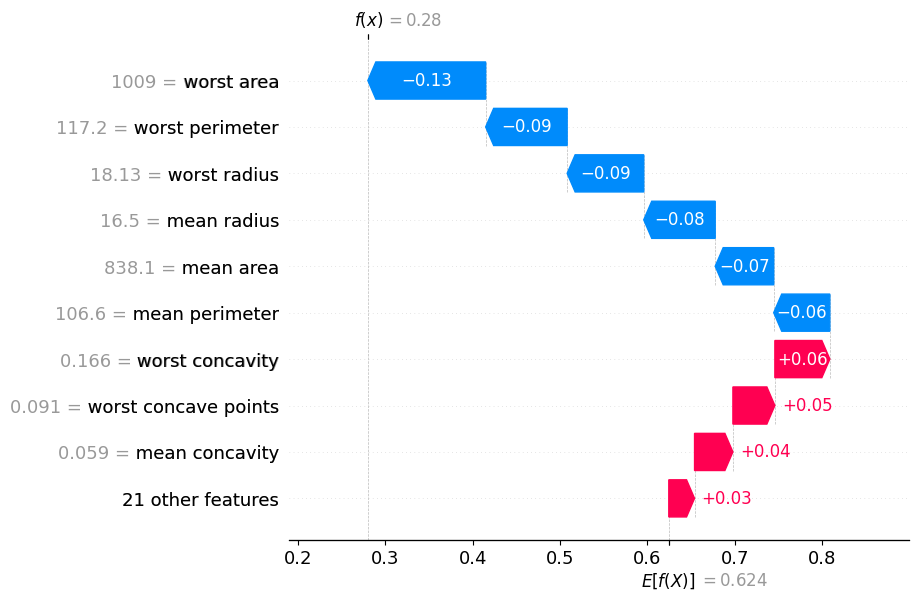

In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][i, :],
        base_values=explainer.expected_value[1],
        data=sample
    )
)

#### Co zobaczysz

* baseline (np. 0.624)
* cechy przesuwające wynik
* final prediction

#### Interpretacja

SHAP mówi:

> „Ta predykcja powstała jako suma wkładów wszystkich cech”

### 13.3 Anchor

In [25]:
anchor_explainer = AnchorTabular(
    predictor=model.predict,
    feature_names=X_train.columns.tolist()
)

anchor_explainer.fit(X_train.values)

anchor_exp = anchor_explainer.explain(sample.values)

print("Anchor:", anchor_exp.anchor)
print("Precision:", anchor_exp.precision)
print("Coverage:", anchor_exp.coverage)

Anchor: ['worst symmetry <= 0.32', 'mean radius > 15.74']
Precision: 0.975973487986744
Coverage: 0.155


In [26]:
print("Decision: ", model.predict(X_test.iloc[i].values.reshape(1, -1))[0])

Decision:  0


#### Co zobaczysz

```text
IF worst symmetry <= 0.32 AND mean radius > 15.74
THEN class = malignant
Precision = 975973487986744
```

#### Interpretacja

Anchor mówi:

> „Jeśli te warunki są spełnione, model prawie zawsze podejmie tę decyzję”

### 13.4 ELI5

In [27]:
eli5.show_prediction(model, sample)

#### Co zobaczysz

* lista cech
* zielone / czerwone wpływy
* wartości wag

#### Interpretacja

ELI5 mówi:

> „Te cechy zwiększają, a te zmniejszają predykcję”

### Co każda metoda „mówi”

| metoda | co mówi                  |
| ------ | ------------------------ |
| LIME   | lokalne przybliżenie     |
| SHAP   | dokładny wkład cech      |
| Anchor | reguła IF-THEN           |
| ELI5   | szybka interpretacja wag |


#### TEN SAM PRZYPADEK – RÓŻNE PERSPEKTYWY

##### LIME

„w tej okolicy działa tak”

##### SHAP

„dokładnie tyle każda cecha wnosi”

##### Anchor

„te warunki wystarczą do decyzji”

##### ELI5

„te cechy pomagają / przeszkadzają”

#### Dogłębna analiza

To jest bardzo dobry zestaw do analizy — i co ważne: **większość metod mówi spójną historię, ale każda z innej perspektywy**. Rozbijmy to konkretnie.

##### 1. Co mówi model (punkt wyjścia):

* SHAP: `f(x) = 0.28` vs baseline `0.624`
    * predykcja spadła → model skłania się ku **klasie 0**
* ELI5: `y = 0 (0.72)`
    * model dość pewny decyzji

##### 2. Główna historia (co napędza decyzję):

**W stronę klasy 0 (ELI5, SHAP)**

Najsilniejsze cechy:

* `worst area`
* `worst perimeter`
* `worst radius`
* `mean radius`
* `mean area`

Wszystkie:

> **duży rozmiar guza**


**W stronę klasy przeciwnej**

* `worst concavity`
* `worst concave points`
* `mean concavity`

Czyli:

> **nieregularność (która zwykle sugeruje malignant)**

**Czyli co?**

Mamy konflikt:

> rozmiar → klasa 0
>
> nieregularność → przeciwna strona

Model „waży” te sygnały i wygrywa rozmiar

##### 3. LIME – lokalne przybliżenie

```bash
worst concave points → +
mean perimeter → -
mean radius → -
mean area → -
```

Interpretacja:
* rozmiar (perimeter, radius, area) → ciągnie do klasy 0
* concavity → przeciwny sygnał

Jest to **zgodne z SHAP**.

##### 4. SHAP – dokładna dekompozycja

```bash
- worst area -0.13
- worst perimeter -0.09
- ...
+ worst concavity +0.06
```

Bardzo klarowne:
* rozmiar = dominujący sygnał
* nieregularność = kontrsygnał

Jest to najbardziej „czysta” interpretacja

##### 5. ELI5 – ranking wpływów

Praktycznie kopia SHAP (co jest bardzo dobrym znakiem):
* TOP:

  * `worst area`
  * `worst perimeter`
  * `mean radius`

* NEGATYWNE:

  * `worst concavity`
  * `worst concave points`

_Póki co mamy **wysoką zgodność metod**_ - TO DOBRZE!

##### 6. Anchor – reguła decyzyjna

```bash
['worst symmetry <= 0.32', 'mean radius > 15.74']
Precision: 0.97
```

Interpretacja:

> Jeśli guz jest duży (mean radius) i względnie regularny (symmetry), to model prawie zawsze wybiera klasę 0

**Co to wnosi?**

Anchor mówi:

> „nie wszystko jest ważne — wystarczy TO”

Czyli redukuje model do minimalnej reguły.

##### 7. Czy metody są spójne?

**TAK — nawet bardzo**

Wszystkie wskazują:

* główny driver:
    * **rozmiar guza**
* przeciwny sygnał:
    * **nieregularność**

---

A więc mamy przypadek:

> duży guz, ale umiarkowanie nieregularny

Model mówi:

> „rozmiar wygrywa”

##### 8. Czy model działa dobrze?

* Pozytywne sygnały:
    * zgodność metod (SHAP ≈ ELI5 ≈ LIME)
    * sensowne cechy (medycznie logiczne)
    * Anchor ma wysoką precision (~0.97)
* Potencjalne ryzyko:
    * konflikt cech (rozmiar vs concavity)
    * model może być:
        * bardziej „size-driven” niż powinien

##### 9. Co można wyczytać?

Model:

* uczy się realnych zależności
* ale może nadmiernie ufać rozmiarowi

### PODSUMOWANIE

> „Która metoda mówi prawdę?”

#### Odpowiedź:

**wszystkie i żadna**

#### Dlaczego?

* LIME → przybliżenie
* SHAP → matematycznie spójne
* Anchor → uproszczenie do reguł
* ELI5 → zależne od modelu

> „To nie są sprzeczne odpowiedzi — to różne języki opisu tego samego modelu”

> Wszystkie metody są spójne i wskazują, że decyzja modelu wynika głównie z dużego rozmiaru guza, mimo że cechy związane z nieregularnością sugerują przeciwną klasę; oznacza to, że model działa sensownie, ale jego decyzja w tym przypadku wynika z kompromisu między sprzecznymi sygnałami.

> „Czy ten przypadek jest trudny dla modelu?”

> TAK — bo cechy dają sprzeczne sygnały

### Jak to tłumaczyć

Porównanie do medycyny:

* SHAP → dokładne badania
* LIME → szybka diagnoza
* Anchor → prosta reguła („jeśli X i Y → choroba”)
* ELI5 → opis lekarza

> SHAP mówi „ile”, LIME mówi „jak lokalnie”, Anchor mówi „kiedy”, a ELI5 mówi „w prosty sposób”.


## Zadania do przećwiczenia **_na innym zbiorze danych_** (opcjonalne, do przećwiczenia samodzielnie)

1. Zrób Anchor dla 2 obserwacji
2. Porównaj reguły
3. Zrób ELI5 dla tej samej próbki
4. Porównaj z SHAP